# Kinematic plots for different networks

## Initialisation

In [2]:
import sys
import json
import argparse
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from pathlib import Path
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, List
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colorbar import Colorbar
from dataclasses import dataclass

# Get main path of the repository and add it to the path:
try:
    # For scripts
    repo_path = Path(__file__).parent.parent.parent.resolve()
except NameError:
    # For Jupyter notebooks - add the known project root
    repo_path = Path.cwd().parent.parent.resolve()

# # Add repository to path
# sys.path.insert(0, str(repo_path))

# from ml_events_utils import stylesheet_default
# # from ml_events_utils import color_gio as color_dict
# from ml_events_utils import color_deep as color_dict

import plot_utils as pu
from plot_utils import network_labels, network_colors, observables_latex, order_latex, stylesheet_default, color_dict

# Plot directory:
plot_dir = repo_path / "final_results" / "plots" / "network_comparison"
plot_dir.mkdir(parents=True, exist_ok=True)


plt.style.use(stylesheet_default)

Observables:

- $\sigma_{\mathrm{tot}}$:     (NN/ POWHEG: `totxsec`,    RFR: ``)
- $p_{T, \, e^{+}}$:            (NN/ POWHEG: `ptep`,       RFR: `ptep`)
- $y_{e^{+}}$:                 (NN/ POWHEG: `yep`,        RFR: `yep`)
- $\cos(\theta^{*}_{e^{+}})$:  (NN/ POWHEG: `cthep`,      RFR: `cthep`)
- $m_{Z}$:                     (NN/ POWHEG: `invmass_Z1`, RFR: `mepem`)
- $\Delta \phi_{ee}$:          (NN/ POWHEG: `dphiee`,     RFR: `dphiee`)  # TODO: Adjust LaTex
- $p_{T, \, Z}$:                  (NN/ POWHEG: `ptee`,       RFR: ``)
- $p_{T, \, 4l}$:              (NN/ POWHEG: `pt4l`,       RFR: `pt4l`)
- $r_{\mathrm{LL}}$:           (NN:         `r_LL`,       RFR: `rll`)

In [3]:
from data_utils import HistogramData


observables = {
    "totxsec": {"Autoencoder": "totxsec",    "FFNN": "totxsec",    "PN": "totxsec",    "POWHEG": "totxsec",    "RFR": None    },
    "ptep":    {"Autoencoder": "ptep",       "FFNN": "ptep",       "PN": "ptep",       "POWHEG": "ptep",       "RFR": "ptep"  },
    "yep":     {"Autoencoder": "yep",        "FFNN": "yep",        "PN": "yep",        "POWHEG": "yep",        "RFR": "yep"   },
    "cthep":   {"Autoencoder": "cthep",      "FFNN": "cthep",      "PN": "cthep",      "POWHEG": "cthep",      "RFR": "cthep" },
    "mepem":   {"Autoencoder": "invmass_Z1", "FFNN": "invmass_Z1", "PN": "invmass_Z1", "POWHEG": "invmass_Z1", "RFR": "mepem" },
    "dphiee":  {"Autoencoder": "dphiee",     "FFNN": "dphiee",     "PN": "dphiee",     "POWHEG": "dphiee",     "RFR": "dphiee"},
    "ptee":    {"Autoencoder": "ptee",       "FFNN": "ptee",       "PN": "ptee",       "POWHEG": "ptee",       "RFR": None    },
    "pt4l":    {"Autoencoder": "pt4l",       "FFNN": "pt4l",       "PN": "pt4l",       "POWHEG": "pt4l",       "RFR": "pt4l"  },
    "rll":     {"Autoencoder": "r_LL",       "FFNN": "r_LL",       "PN": "r_LL",       "POWHEG": "r_LL",       "RFR": "rll"   },
}

print(f"Get observables like this: {observables['totxsec']['FFNN'] = }.")

HistogramData.colors = network_colors

HistogramData.labels = network_labels

Get observables like this: observables['totxsec']['FFNN'] = 'totxsec'.


## Load the data

1. Put path of the analysis files in dictionary.

In [4]:
autoencoder_path  = repo_path / "final_results" / "autoencoder"
ffnn_path         = repo_path / "final_results" / "ffnn"
pn_path           = repo_path / "final_results" / "pn"
powheg_path       = repo_path / "final_results" / "powheg"
rfr_path          = repo_path / "random_forest_regression"

# Define paths to histogram files and a rescaling factor for each model and order:
# Autoencoder, FFNN, POWHEG are in pb, so we need to rescale it by 1e3 to compare with RFR.
# RFR is in fb.
histogram_paths = {
    "Autoencoder": {
            "LO":    [autoencoder_path / "LO"    / "LO_evts"    / "LL_pred.top", 1e3],
            "LOwS":  [autoencoder_path / "LOwS"  / "LOwS_evts"  / "LL_pred.top", 1e3],
            "NLO":   [None, 1e3],
            "NLOPS": [autoencoder_path / "NLOPS" / "NLOPS_evts" / "LL_pred.top", 1e3],
           },
    "FFNN": {
            "LO":    [ffnn_path / "LO"    / "LO_evts"    / "LL_pred.top", 1e3],
            "LOwS":  [ffnn_path / "LOwS"  / "LOwS_evts"  / "LL_pred.top", 1e3],
            "NLO":   [None, 1e3],
            "NLOPS": [ffnn_path / "NLOPS" / "NLOPS_evts" / "LL_pred.top", 1e3],
           },
    "PN": {
            "LO":    [pn_path / "LO"  / "LL_pred.top", 1e3],
            "LOwS":  [None, 1e3],
            "NLO":   [pn_path / "NLO" / "LL_pred.top", 1e3],
            "NLOPS": [None, 1e3],
           },
    "POWHEG": {
            # "LO":    [powheg_path / "LO"    / "POWHEG_LL.top", 1e3],
            "LO":    [powheg_path / "LO"    / "LL_true.top", 1e3],
            "LOwS":  [powheg_path / "LOwS"  / "LL_true.top", 1e3],
            "NLO":   [None, 1e3],
            "NLOPS": [powheg_path / "NLOPS" / "LL_true.top", 1e3],
           },
    "RFR": {
            "LO":    [rfr_path / "histograms_rfr_ct_lo.top",    1.0],
            "LOwS":  [rfr_path / "histograms_rfr_ct_lows.top",  1.0],
            "NLO":   [rfr_path / "histograms_rfr_ct_nlo.top",   1.0],
            "NLOPS": [rfr_path / "histograms_rfr_ct_nlops.top", 1.0],
            "NLOPSep": [rfr_path / "histograms_rfr_ep_nlops.top", 1.0],
           },
}

# Check that files exist:
for model, model_paths in histogram_paths.items():
    for order, (path, _) in model_paths.items():
        if path is not None and not path.exists():
            raise FileNotFoundError(f"File for {model} @ {order} does not exist: {path}")

print(f"Get paths like this: {histogram_paths['RFR']['LO'] = }.")

Get paths like this: histogram_paths['RFR']['LO'] = [PosixPath('/Users/linder/polarisation_tagging/random_forest_regression/histograms_rfr_ct_lo.top'), 1.0].


2. Read in the histograms and align observable names.

In [5]:
from data_utils import read_histogram

model_histograms = {}
for model, model_paths in histogram_paths.items():
    model_histograms[model] = {}
    observable_map_model = {obs_info[model]: obs for obs, obs_info in observables.items()}
    for order, (path, rescaling_factor) in model_paths.items():
        if path is not None:
            print(f"Reading histogram for {model} @ {order} from {path}.")
            model_histograms[model][order] = read_histogram(path, rescaling_factor, observable_map=observable_map_model, name=model, order=order)
            print(f"Available observables for {model} @ {order}: {list(model_histograms[model][order].keys())}")

# test_histogram = read_histogram(histogram_paths["RFR"]["LO"][0], histogram_paths["RFR"]["LO"][1], observable_map=observables, name="RFR")

print(f"Get histograms like this: {model_histograms['RFR']['LO']['ptep'] = }.")
print(f"Access bins like this: {model_histograms['RFR']['LO']['ptep'].bins = }.")
print("Have fun plotting! :)")

Reading histogram for Autoencoder @ LO from /Users/linder/polarisation_tagging/final_results/autoencoder/LO/LO_evts/LL_pred.top.
Available observables for Autoencoder @ LO: ['totxsec', 'mepem', 'ptee', 'r_LL_ptee', 'cthep', 'ptep', 'yep', 'pt4l', 'dphiee', 'rll', 'r_LL_count']
Reading histogram for Autoencoder @ LOwS from /Users/linder/polarisation_tagging/final_results/autoencoder/LOwS/LOwS_evts/LL_pred.top.
Available observables for Autoencoder @ LOwS: ['totxsec', 'mepem', 'ptee', 'r_LL_ptee', 'cthep', 'ptep', 'yep', 'pt4l', 'dphiee', 'rll', 'r_LL_count']
Reading histogram for Autoencoder @ NLOPS from /Users/linder/polarisation_tagging/final_results/autoencoder/NLOPS/NLOPS_evts/LL_pred.top.
Available observables for Autoencoder @ NLOPS: ['totxsec', 'mepem', 'ptee', 'r_LL_ptee', 'cthep', 'ptep', 'yep', 'pt4l', 'dphiee', 'rll', 'r_LL_count']
Reading histogram for FFNN @ LO from /Users/linder/polarisation_tagging/final_results/ffnn/LO/LO_evts/LL_pred.top.
Available observables for FFNN 

## Plotting routine for ordinary kinematic data

In [6]:
def get_histograms_for_observable(histograms, observable, order):
    histograms_for_observable = {}
    for model, model_histograms in histograms.items():
        if order in model_histograms and observable in model_histograms[order]:
            histograms_for_observable[model] = model_histograms[order][observable]
    return histograms_for_observable


def plot_observable_function(histograms: dict,
                             xrange: list,
                             title:str,
                             xlabel:str,
                             unit:str,
                             ylabel1:str,
                             yranges:list=[],
                             logs:list = [False, False],
                             legends:list=[{}, {}],
                             rcParams:dict={},):

    """
    histogram: dict = {
                       "model1": histogram,
                       "model2": histogram,
                      }
    Plots:
        Oben:
        Ratio1:
        Ratio2:
    """

    with plt.style.context(stylesheet_default):
        n_plots = 2
        fig, axs = pu.create_subplots(n_plots, rcParams)
        ylabels = ["",] * n_plots

        for key, run in histograms.items():
            histograms[key] = run[slice(*xrange)]

        iplot = 0
        weights_sig = []
        styles = []
        labels = [HistogramData.labels.get(key.lower(), key) for key in histograms.keys()]
        for histogram in histograms.values():
            weights_sig.append((histogram.bins, histogram.values, histogram.errors))
            styles.append(histogram.style)

        pu.plot_histograms(axs[iplot], weights_sig, labels=labels, styles=styles, uncertainties=False)
        ylabels[iplot] = ylabel1

        # ratios w.r.t powheg:
        if histograms.get("POWHEG", None):
            ref_histogram = histograms["POWHEG"]
            ref_name = HistogramData.labels.get("POWHEG".lower(), "POWHEG")
        elif histograms.get("RFR", None):
            ref_histogram = histograms["RFR"]
            ref_name = HistogramData.labels.get("RFR".lower(), "RFR")
        else:
            ref_histogram = list(histograms.values())[0]
            ref_name = HistogramData.labels.get(ref_histogram.name, ref_histogram.name)

        iplot = 1
        weights_sig = []
        styles = []
        for i, (model, histogram) in enumerate(histograms.items()):
            if model == "POWHEG":
                continue
            ratio_histogram = histogram / ref_histogram
            weights_sig.append((ratio_histogram.bins, ratio_histogram.values, ratio_histogram.errors))
            styles.append(histogram.style)

        pu.plot_histograms(axs[iplot], weights_sig, labels=None, styles=styles, uncertainties=False)
        axs[iplot].axhline(1.0, color=color_dict['black'], linestyle='--', linewidth=1)

        ylabels[iplot] = f"ratio to {ref_name}"

        axs[iplot].text(
            0.02,
            0.92,
            ylabels[iplot],
            transform=axs[iplot].transAxes,
            va='top',
            ha='left',
            # bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8, "edgecolor": "gray"},
        )
        ylabels[iplot] = ""

        axs[0].set_title(title)
        if unit:
            xlabel  += f" [{unit}]"

        axs[n_plots-1].set_xlabel(xlabel)

        pu.move_offset_factor(axs[0], ylabels[0])
        for i, log, yrange, legend in zip(list(range(n_plots)), logs, yranges, legends):
            axs[i].set_ylabel(ylabels[i])
            if log:
                axs[i].set_yscale('log')
            if yrange:
                axs[i].set_ylim(yrange)

            if legend:
                pu.add_legend(axs[i], **legend)
            else:
                pu.add_legend(axs[i], legloc="lower left")

            pu.move_offset_factor(axs[i], ylabels[i])


        return fig, axs

### Input

Plotting observable cthep @ LO.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


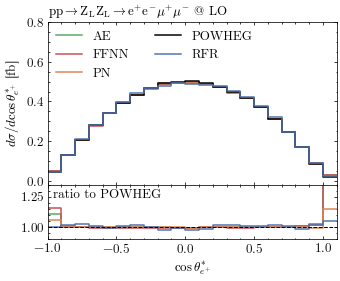

Plotting observable cthep @ LO.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


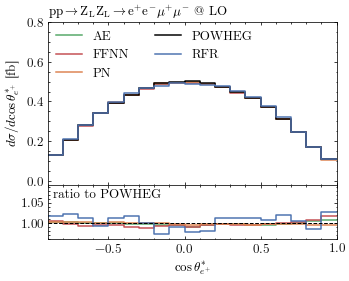

Plotting observable ptep @ LO.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


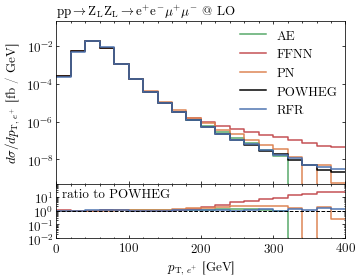

Plotting observable yep @ LO.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


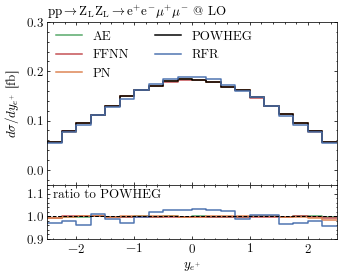

Plotting observable mepem @ LO.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


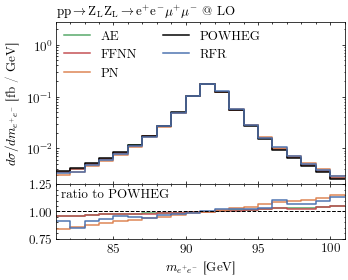

Plotting observable dphiee @ LO.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


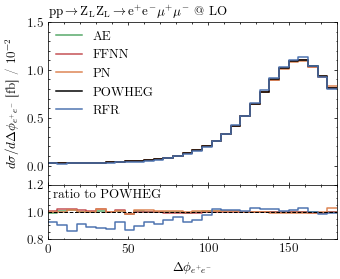

Plotting observable ptee @ LO.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


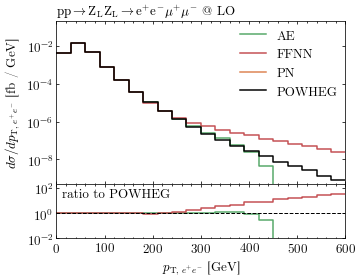

Plotting observable rll @ LO.


/Users/linder/polarisation_tagging/final_results/plots/data_utils.py:143: RuntimeWarning: divide by zero encountered in divide
  new_values = self.values / other.values
/Users/linder/polarisation_tagging/final_results/plots/data_utils.py:145: RuntimeWarning: invalid value encountered in divide
  new_errors = np.sqrt((self.errors / other.values)**2 + ( self.values * other.errors / other.values**2 )**2)
/Users/linder/polarisation_tagging/final_results/plots/data_utils.py:143: RuntimeWarning: invalid value encountered in divide
  new_values = self.values / other.values
/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


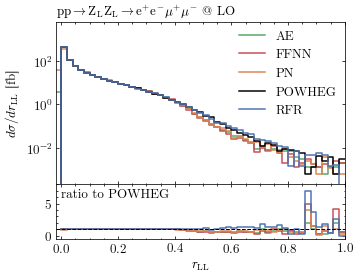

Plotting observable rll @ LO.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


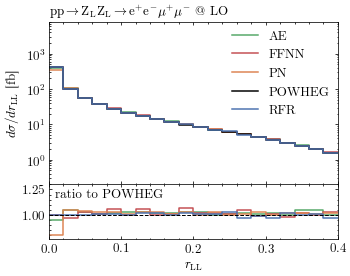

Plotting observable cthep @ LOwS.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


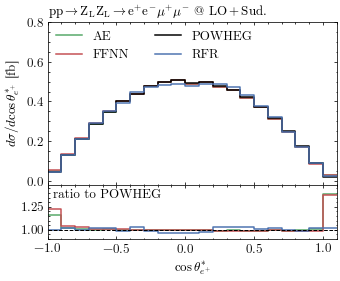

Plotting observable ptep @ LOwS.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


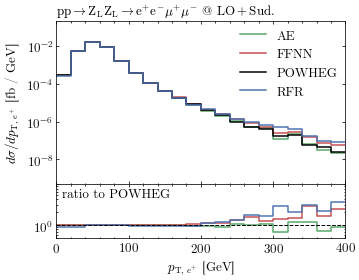

Plotting observable yep @ LOwS.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


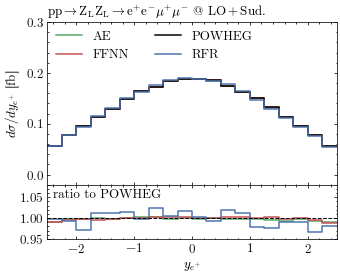

Plotting observable mepem @ LOwS.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


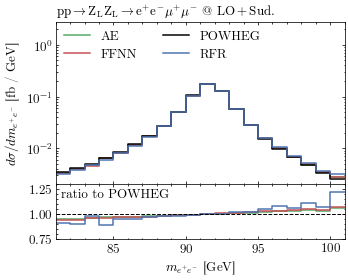

Plotting observable dphiee @ LOwS.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


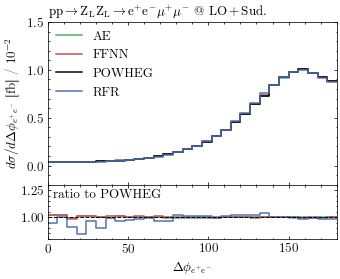

Plotting observable ptee @ LOwS.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


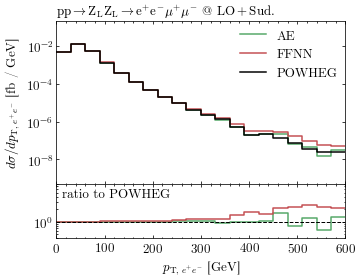

Plotting observable pt4l @ LOwS.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


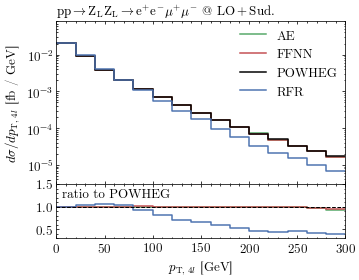

Plotting observable rll @ LOwS.


/Users/linder/polarisation_tagging/final_results/plots/data_utils.py:143: RuntimeWarning: divide by zero encountered in divide
  new_values = self.values / other.values
/Users/linder/polarisation_tagging/final_results/plots/data_utils.py:145: RuntimeWarning: invalid value encountered in divide
  new_errors = np.sqrt((self.errors / other.values)**2 + ( self.values * other.errors / other.values**2 )**2)
/Users/linder/polarisation_tagging/final_results/plots/data_utils.py:143: RuntimeWarning: invalid value encountered in divide
  new_values = self.values / other.values
/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


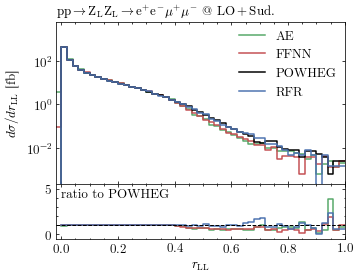

Plotting observable cthep @ NLO.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


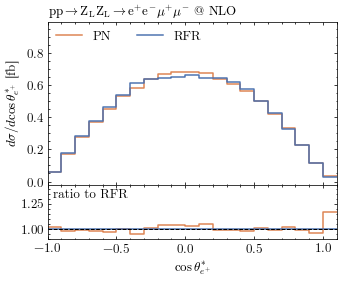

Plotting observable ptep @ NLO.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


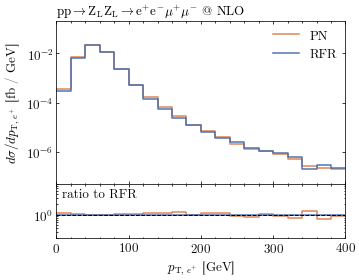

Plotting observable yep @ NLO.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


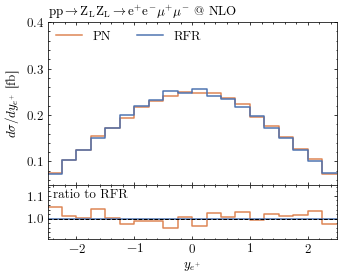

Plotting observable mepem @ NLO.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


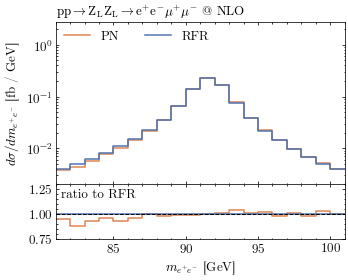

Plotting observable dphiee @ NLO.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


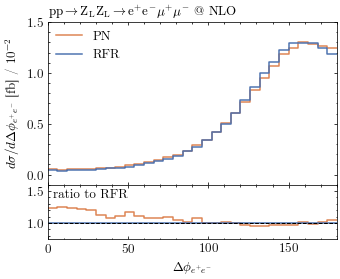

Plotting observable pt4l @ NLO.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


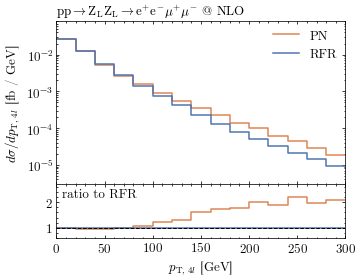

Plotting observable rll @ NLO.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


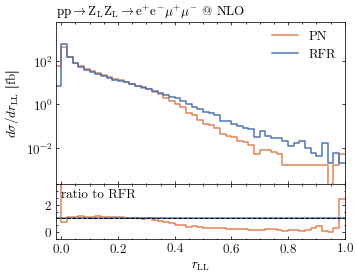

Plotting observable cthep @ NLOPS.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


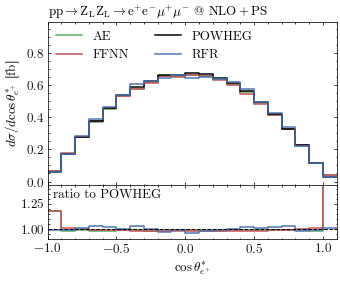

Plotting observable cthep @ NLOPS.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


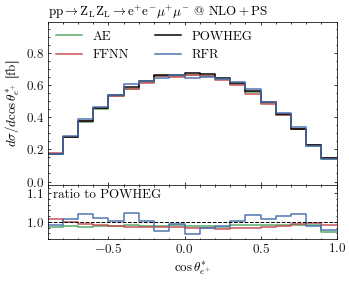

Plotting observable ptep @ NLOPS.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


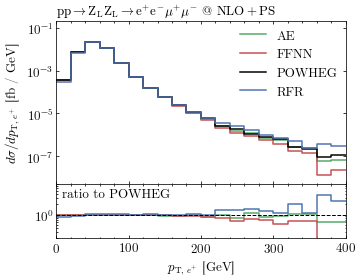

Plotting observable yep @ NLOPS.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


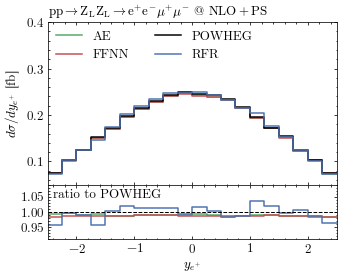

Plotting observable mepem @ NLOPS.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


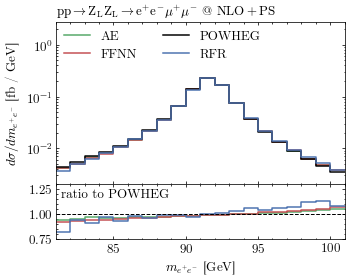

Plotting observable dphiee @ NLOPS.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


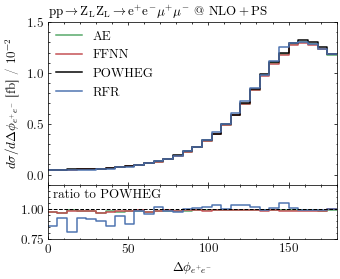

Plotting observable ptee @ NLOPS.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


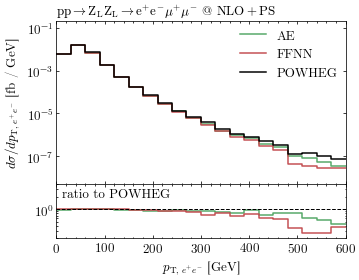

Plotting observable pt4l @ NLOPS.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


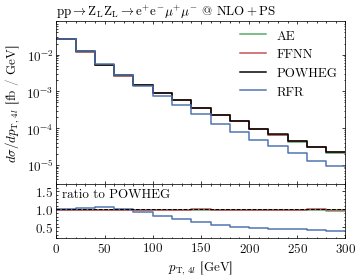

Plotting observable rll @ NLOPS.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


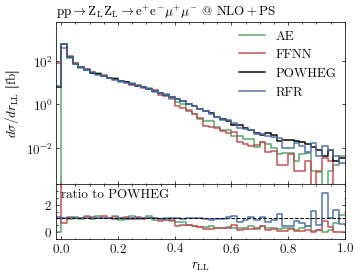

Plotting observable rll @ NLOPS.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


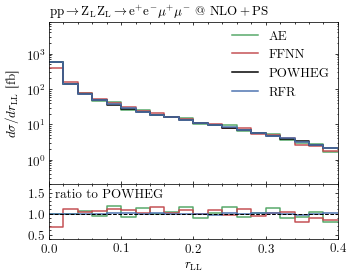

In [7]:


metadata = {'Title': "Kinematic distributions for different models",
            'Author': 'Jakob Linder',
            'CreationDate': datetime.today(),
            'ModDate': datetime.today(),
            'Creator': 'Python'}

fp_rcParams = {}

for order in ["LO", "LOwS", "NLO", "NLOPS"]:
# for order in ["LO", ]:
    file = plot_dir / Path(f"network_comparison_{order.lower()}.pdf")
    metadata['Title'] = f"Kinematic distributions for different models @ {order}"
    if order == "LO":
        plot_observables = {
            # observables_key: [tex_xlabel, unit, xrange and bin width, [yrange1, yrange2], [log1, log2], [legend1, legend2]]  # default xrange
            ("cthep" , object())  : [observables_latex["cthep"],   r"",    [ -1.,  +1.,  0.1], [[-0.02,      0.8], [0.9,  1.35]], [False, False], [{"legloc": "upper left", "ncol": 2}, {}], ],  # [ -1.,  +1., 0.05]
            ("cthep" , object())  : [observables_latex["cthep"],   r"",    [-0.9, +0.9,  0.1], [[-0.02,      0.8], [0.96, 1.095]], [False, False], [{"legloc": "upper left", "ncol": 2}, {}], ],  # [ -1.,  +1., 0.05]
            ("ptep"  , object())  : [observables_latex["ptep"],    r"GeV", [  0., 400.,  20.], [[5e-10,     2e-1], [1e-2,  8e1]], [True,   True], [{"legloc": "upper right"}, {}],   ],  # [  0., 400.,  10.]
            ("yep"   , object())  : [observables_latex["yep"],     r"",    [-2.5, +2.5,     ], [[-0.03,     0.30], [0.9,  1.14]], [False, False], [{"legloc": "upper left", "ncol": 2}, {}], ],  # [-2.5, +2.5, 0.05]
            ("mepem" , object())  : [observables_latex["mepem"],   r"GeV", [ 81., 101.,   1.], [[2e-3,     2.8e0], [0.75, 1.25]], [True,  False], [{"legloc": "upper left", "ncol": 2}, {}], ],  # [ 81., 101.,  0.5]
            ("dphiee", object())  : [observables_latex["dphiee"],  r"",    [  0., 180.,   6.], [[-0.2e-2, 1.5e-2], [0.8,   1.2]], [False, False], [{"legloc": "upper left"}, {}],   ],  # [  0., 180.,   6.]
            ("ptee"  , object())  : [observables_latex["ptee"],    r"GeV", [  0., 600.,  30.], [[5e-10,     2e-1], [1e-2,  2e2]], [True,   True], [{"legloc": "upper right"}, {}],  ],  # [  0., 600.,  15.]
            ("rll"   , object())  : [observables_latex["rll"],     r"",    [-0.02,  1., 0.02], [[2e-4,       6e3], [-0.5,  8.0]], [True,  False], [{"legloc": "upper right"}, {}], ],   # [ -0.02,   1., 0.01]
            ("rll"   , object())  : [observables_latex["rll"],     r"",    [ 0.0, 0.4, 0.02],  [[2e-1,       8e3], [0.76,  1.3]], [True,  False], [{"legloc": "upper right"}, {}], ],   # [ -0.02,   1., 0.01]
        }
    elif order == "LOwS":
        plot_observables = {
            # observables_key: [tex_xlabel, unit, xrange and bin width, [yrange1, yrange2], [log1, log2], [legend1, legend2]]  # default xrange
            ("cthep" , object())  : [observables_latex["cthep"],   r"",    [ -1.,  +1.,  0.1], [[-0.02,      0.8], [0.9,  1.49]], [False, False], [{"legloc": "upper left", "ncol": 2}, {}], ],  # [ -1.,  +1., 0.05]
            ("ptep"  , object())  : [observables_latex["ptep"],    r"GeV", [  0., 400.,  20.], [[5e-10,     2e-1], [5e-1,  9e0]], [True,   True], [{"legloc": "upper right"}, {}],   ],  # [  0., 400.,  10.]
            ("yep"   , object())  : [observables_latex["yep"],     r"",    [-2.5, +2.5,     ], [[-0.02,     0.30], [0.95, 1.08]], [False, False], [{"legloc": "upper left", "ncol": 2}, {}], ],  # [-2.5, +2.5, 0.05]
            ("mepem" , object())  : [observables_latex["mepem"],   r"GeV", [ 81., 101.,   1.], [[2e-3,     2.8e0], [0.75, 1.30]], [True,  False], [{"legloc": "upper left", "ncol": 2}, {}], ],  # [ 81., 101.,  0.5]
            ("dphiee", object())  : [observables_latex["dphiee"],  r"",    [  0., 180.,   6.], [[-0.2e-2, 1.5e-2], [0.8,   1.3]], [False, False], [{"legloc": "upper left"}, {}],   ],  # [  0., 180.,   6.]
            ("ptee"  , object())  : [observables_latex["ptee"],    r"GeV", [  0., 600.,  30.], [[5e-10,     2e-1], [4e-1,  8e0]], [True,   True], [{"legloc": "upper right"}, {}],  ],  # [  0., 600.,  15.]
            ("pt4l"  , object())  : [observables_latex["pt4l"],    r"GeV", [  0., 300.,  20.], [[3e-6,      8e-2], [0.3,   1.5]], [True,  False], [{"legloc": "upper right"}, {}],  ],  # [  0., 300.,   5.]
            ("rll"   , object())  : [observables_latex["rll"],     r"",    [-0.02,  1., 0.02], [[2e-4,       6e3], [-0.5,  5.5]], [True,  False], [{"legloc": "upper right"}, {}], ],   # [ -0.02,   1., 0.01]
        }
    elif order == "NLO":
        plot_observables = {
            # observables_key: [tex_xlabel, unit, xrange and bin width, [yrange1, yrange2], [log1, log2], [legend1, legend2]]  # default xrange
            ("cthep" , object())  : [observables_latex["cthep"],   r"",    [ -1.,  +1.,  0.1], [[-0.02,     0.99], [0.9,  1.44]], [False, False], [{"legloc": "upper left", "ncol": 2}, {}], ],  # [ -1.,  +1., 0.05]
            ("ptep"  , object())  : [observables_latex["ptep"],    r"GeV", [  0., 400.,  20.], [[5e-8,      2e-1], [2e-1,  8e0]], [True,   True], [{"legloc": "upper right"}, {}],   ],  # [  0., 400.,  10.]
            ("yep"   , object())  : [observables_latex["yep"],     r"",    [-2.5, +2.5,     ], [[0.05,      0.40], [0.91, 1.15]], [False, False], [{"legloc": "upper left", "ncol": 2}, {}], ],  # [-2.5, +2.5, 0.05]
            ("mepem" , object())  : [observables_latex["mepem"],   r"GeV", [ 81., 101.,   1.], [[2e-3,     2.8e0], [0.75, 1.30]], [True,  False], [{"legloc": "upper left", "ncol": 2}, {}], ],  # [ 81., 101.,  0.5]
            ("dphiee", object())  : [observables_latex["dphiee"],  r"",    [  0., 180.,   6.], [[-1e-3,   1.5e-2], [0.75,  1.6]], [False, False], [{"legloc": "upper left"}, {}],   ],  # [  0., 180.,   6.]
            # ("ptee", object())    : [observables_latex["ptee"],    r"GeV", [  0., 600.,  30.], [[5e-9,      2e-1], [2e-1,  4e0]], [True,   True], [{"legloc": "upper right"}, {}],  ],  # [  0., 600.,  15.]
            ("pt4l"  , object())  : [observables_latex["pt4l"],    r"GeV", [  0., 300.,  20.], [[3e-6,      8e-2], [0.6,   2.7]], [True,  False], [{"legloc": "upper right"}, {}],  ],  # [  0., 300.,   5.]
            ("rll"   , object())  : [observables_latex["rll"],     r"",    [-0.02,  1., 0.02], [[2e-4,       6e3], [-0.5,  3.5]], [True,  False], [{"legloc": "upper right"}, {}], ],   # [ -0.02,   1., 0.01]
        }
    elif order == "NLOPS":
        plot_observables = {
            # observables_key: [tex_xlabel, unit, xrange and bin width, [yrange1, yrange2], [log1, log2], [legend1, legend2]]  # default xrange
            ("cthep" , object())  : [observables_latex["cthep"],   r"",    [ -1.,  +1.,  0.1], [[-0.02,     0.99], [0.9,  1.44]], [False, False], [{"legloc": "upper left", "ncol": 2}, {}], ],  # [ -1.,  +1., 0.05]
            ("cthep" , object())  : [observables_latex["cthep"],   r"",    [-0.9, +0.9,  0.1], [[-0.02,     0.99], [0.94, 1.13]], [False, False], [{"legloc": "upper left", "ncol": 2}, {}], ],  # [ -1.,  +1., 0.05]
            ("ptep"  , object())  : [observables_latex["ptep"],    r"GeV", [  0., 400.,  20.], [[5e-9,      2e-1], [2e-1,  8e0]], [True,   True], [{"legloc": "upper right"}, {}],   ],  # [  0., 400.,  10.]
            ("yep"   , object())  : [observables_latex["yep"],     r"",    [-2.5, +2.5,     ], [[0.05,      0.40], [0.91, 1.09]], [False, False], [{"legloc": "upper left", "ncol": 2}, {}], ],  # [-2.5, +2.5, 0.05]
            ("mepem" , object())  : [observables_latex["mepem"],   r"GeV", [ 81., 101.,   1.], [[2e-3,     2.8e0], [0.75, 1.30]], [True,  False], [{"legloc": "upper left", "ncol": 2}, {}], ],  # [ 81., 101.,  0.5]
            ("dphiee", object())  : [observables_latex["dphiee"],  r"",    [  0., 180.,   6.], [[-1e-3,   1.5e-2], [0.75,  1.2]], [False, False], [{"legloc": "upper left"}, {}],   ],  # [  0., 180.,   6.]
            ("ptee"  , object())  : [observables_latex["ptee"],    r"GeV", [  0., 600.,  30.], [[5e-9,      2e-1], [2e-1,  4e0]], [True,   True], [{"legloc": "upper right"}, {}],  ],  # [  0., 600.,  15.]
            ("pt4l"  , object())  : [observables_latex["pt4l"],    r"GeV", [  0., 300.,  20.], [[3e-6,      8e-2], [0.2,   1.7]], [True,  False], [{"legloc": "upper right"}, {}],  ],  # [  0., 300.,   5.]
            ("rll"   , object())  : [observables_latex["rll"],     r"",    [-0.02,  1., 0.02], [[2e-4,       6e3], [-0.5,  3.5]], [True,  False], [{"legloc": "upper right"}, {}], ],   # [ -0.02,   1., 0.01]
            ("rll"   , object())  : [observables_latex["rll"],     r"",    [  0.0, 0.4, 0.02], [[2e-1,       8e3], [0.4,  1.7]], [True,  False], [{"legloc": "upper right"}, {}], ],   # [ -0.02,   1., 0.01]
        }


    # Set rebinned bins explicitly as list in order to avoid rounding issues.
    # for key in plot_observables.keys():
    #     if len(plot_observables[key][2]) == 3:
    #         plot_observables[key][2][2] = np.arange(plot_observables[key][2][0], plot_observables[key][2][1] + plot_observables[key][2][2], plot_observables[key][2][2])


    with PdfPages(filename=file, metadata=metadata) as pdf:
        for (fp_observable, _), (fp_xlabel, fp_unit, fp_xrange, fp_yranges, fp_logs, fp_legends) in plot_observables.items():
            print(f"Plotting observable {fp_observable} @ {order}.")

            histograms = get_histograms_for_observable(model_histograms, fp_observable, order)

            fp_title  = r"$\mathrm{p} \mathrm{p} \rightarrow \mathrm{Z}_{\mathrm{L}} \mathrm{Z}_{\mathrm{L}} \rightarrow \mathrm{e}^{+} \mathrm{e}^{-} \mu^{+} \mu^{-}$ @ " + order_latex[order.lower()]
            fp_ylabel1 = r"$d \sigma / d " + fp_xlabel[1:-1] + r"$ [fb]"
            if fp_unit:
                fp_ylabel1 = fp_ylabel1[:-1] + f" / {fp_unit}]"


            fig, axs = plot_observable_function(histograms,
                                                xrange=fp_xrange,
                                                title=fp_title,
                                                xlabel=fp_xlabel,
                                                unit=fp_unit,
                                                ylabel1=fp_ylabel1,
                                                yranges=fp_yranges,
                                                logs=fp_logs,
                                                legends=fp_legends,
                                                rcParams=fp_rcParams)

            pdf.savefig(fig)
            plt.show()



### RFR input difference
Examine the effect of taking different input data for the random forest (only NLOPS).

Plotting observable cthep @ NLOPS.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


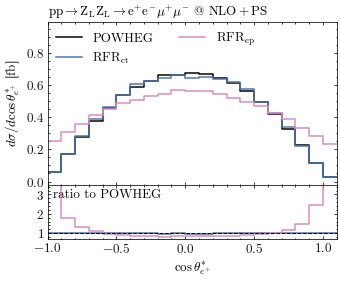

Plotting observable cthep @ NLOPS.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


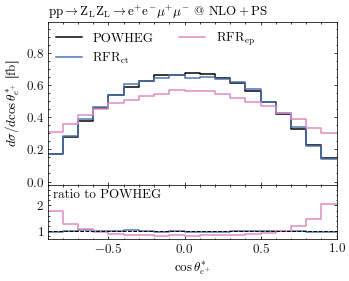

Plotting observable ptep @ NLOPS.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


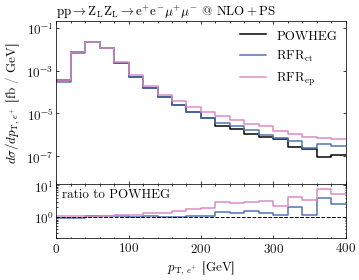

Plotting observable yep @ NLOPS.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


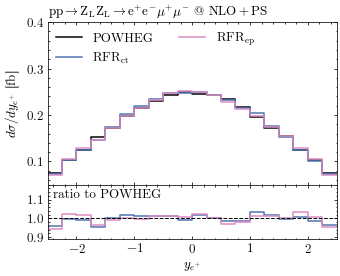

Plotting observable mepem @ NLOPS.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


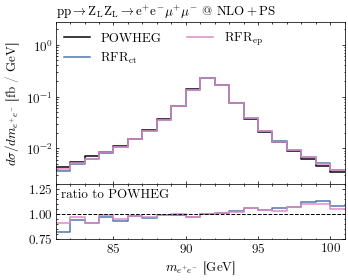

Plotting observable dphiee @ NLOPS.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


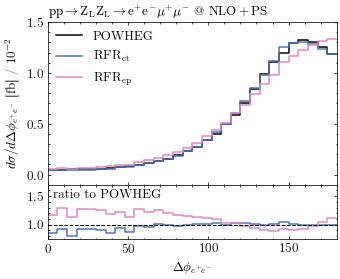

Plotting observable pt4l @ NLOPS.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


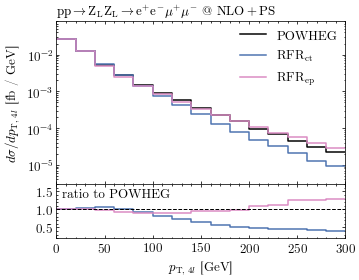

Plotting observable rll @ NLOPS.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


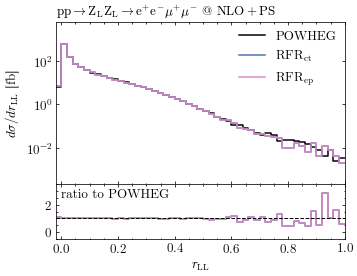

Plotting observable rll @ NLOPS.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


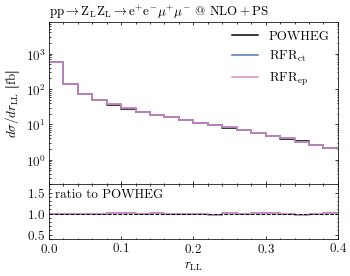

In [8]:
metadata = {'Title': "Kinematic distributions for RFR with different features vs POWHEG @ NLOPS",
            'Author': 'Jakob Linder',
            'CreationDate': datetime.today(),
            'ModDate': datetime.today(),
            'Creator': 'Python'}

fp_rcParams = {}

order_nlops   = "NLOPS"
order_nlopsep = "NLOPSep"

plot_observables = {
    # observables_key: [tex_xlabel, unit, xrange and bin width, [yrange1, yrange2], [log1, log2], [legend1, legend2]]  # default xrange
    ("cthep" , object())  : [observables_latex["cthep"],   r"",    [ -1.,  +1.,  0.1], [[-0.02,     0.99], [0.7, 3.5]], [False, False], [{"legloc": "upper left", "ncol": 2}, {}], ],  # [ -1.,  +1., 0.05]
    ("cthep" , object())  : [observables_latex["cthep"],   r"",    [-0.9, +0.9,  0.1], [[-0.02,     0.99], [0.7, 2.8]], [False, False], [{"legloc": "upper left", "ncol": 2}, {}], ],  # [ -1.,  +1., 0.05]
    ("ptep"  , object())  : [observables_latex["ptep"],    r"GeV", [  0., 400.,  20.], [[5e-9,      2e-1], [2e-1, 1.1e1]], [True,   True], [{"legloc": "upper right"}, {}],   ],  # [  0., 400.,  10.]
    ("yep"   , object())  : [observables_latex["yep"],     r"",    [-2.5, +2.5,     ], [[0.05,      0.40], [0.89, 1.18]], [False, False], [{"legloc": "upper left", "ncol": 2}, {}], ],  # [-2.5, +2.5, 0.05]
    ("mepem" , object())  : [observables_latex["mepem"],   r"GeV", [ 81., 101.,   1.], [[2e-3,     2.8e0], [0.75, 1.30]], [True,  False], [{"legloc": "upper left", "ncol": 2}, {}], ],  # [ 81., 101.,  0.5]
    ("dphiee", object())  : [observables_latex["dphiee"],  r"",    [  0., 180.,   6.], [[-1e-3,   1.5e-2], [0.75,  1.7]], [False, False], [{"legloc": "upper left"}, {}],   ],  # [  0., 180.,   6.]
    ("pt4l"  , object())  : [observables_latex["pt4l"],    r"GeV", [  0., 300.,  20.], [[3e-6,      8e-2], [0.2,   1.7]], [True,  False], [{"legloc": "upper right"}, {}],  ],  # [  0., 300.,   5.]
    ("rll"   , object())  : [observables_latex["rll"],     r"",    [-0.02,  1., 0.02], [[2e-4,       6e3], [-0.5,  3.5]], [True,  False], [{"legloc": "upper right"}, {}], ],   # [ -0.02,   1., 0.01]
    ("rll"   , object())  : [observables_latex["rll"],     r"",    [  0.0, 0.4, 0.02], [[2e-1,       8e3], [0.4,  1.7]], [True,  False], [{"legloc": "upper right"}, {}], ],   # [ -0.02,   1., 0.01]
}


file = plot_dir / Path(f"rfr_input_comparison_{order_nlops.lower()}.pdf")
with PdfPages(filename=file, metadata=metadata) as pdf:
    for (fp_observable, _), (fp_xlabel, fp_unit, fp_xrange, fp_yranges, fp_logs, fp_legends) in plot_observables.items():
        print(f"Plotting observable {fp_observable} @ {order_nlops}.")

        histograms_for_observable = {
                                     "POWHEG": model_histograms["POWHEG"][order_nlops][fp_observable],
                                     "RFRct": model_histograms["RFR"][order_nlops][fp_observable],
                                     "RFRep": model_histograms["RFR"][order_nlopsep][fp_observable],
                                    }

        histograms_for_observable["RFRct"].style["color"] = network_colors["RFRct"]
        histograms_for_observable["RFRep"].style["color"] = network_colors["RFRep"]

        fp_title  = r"$\mathrm{p} \mathrm{p} \rightarrow \mathrm{Z}_{\mathrm{L}} \mathrm{Z}_{\mathrm{L}} \rightarrow \mathrm{e}^{+} \mathrm{e}^{-} \mu^{+} \mu^{-}$ @ " + order_latex[order_nlops.lower()]
        fp_ylabel1 = r"$d \sigma / d " + fp_xlabel[1:-1] + r"$ [fb]"
        if fp_unit:
            fp_ylabel1 = fp_ylabel1[:-1] + f" / {fp_unit}]"


        fig, axs = plot_observable_function(histograms_for_observable,
                                            xrange=fp_xrange,
                                            title=fp_title,
                                            xlabel=fp_xlabel,
                                            unit=fp_unit,
                                            ylabel1=fp_ylabel1,
                                            yranges=fp_yranges,
                                            logs=fp_logs,
                                            legends=fp_legends,
                                            rcParams=fp_rcParams)

        pdf.savefig(fig)
        plt.show()